## Instance Segmentation

In [1]:
import tensorflow as tf
import cv2
import numpy as np
import matplotlib.pyplot as plt

2026-04-13 23:21:12.610390: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776118872.821081   32036 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776118872.889253   32036 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776118873.682369   32036 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776118873.682425   32036 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776118873.682428   32036 computation_placer.cc:177] computation placer alr

## Data Loading

In [2]:
import glob
from tqdm import tqdm
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split

In [3]:
train_dir = "../data/train"
valid_dir = "../data/validation"

In [4]:
train_images_paths, train_masks_paths = shuffle(glob.glob(train_dir+"/images/*.jpeg"), glob.glob(train_dir+"/masks/*.png"), random_state=42)
#train_masks_paths = glob.glob(train_dir+"/masks/*.png")

valid_images_paths, valid_masks_paths = shuffle(glob.glob(valid_dir+"/images/*.jpeg"), glob.glob(valid_dir+"/masks/*.png"), random_state=42)

assert len(train_images_paths) == len(train_masks_paths)
assert len(valid_images_paths) == len(valid_masks_paths)

In [5]:
print(f"Total train images is {len(train_images_paths)}")
print(f"Total validation images is {len(valid_images_paths)}")

Total train images is 4131
Total validation images is 1184


In [6]:
def load_images(path_list):
    loaded_images = []
    for path in path_list:
        loaded_images.append(cv2.imread(path))
    return np.array(loaded_images)

train_images = load_images(train_images_paths)
train_masks = load_images(train_masks_paths)
valid_images = load_images(valid_images_paths)
valid_masks = load_images(valid_masks_paths)

In [7]:
print(f"Train images shape is {train_images.shape}")
print(f"Train masks shape is {train_masks.shape}")
print(f"Valid images shape is {valid_images.shape}")
print(f"Valid masks shape is {valid_masks.shape}")

Train images shape is (4131, 256, 256, 3)
Train masks shape is (4131, 256, 256, 3)
Valid images shape is (1184, 256, 256, 3)
Valid masks shape is (1184, 256, 256, 3)


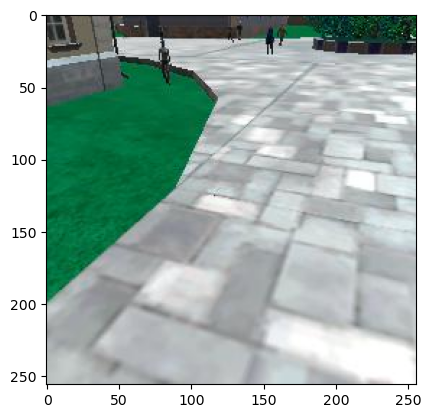

In [8]:
# Visual representation of data
plt.imshow(train_images[1])

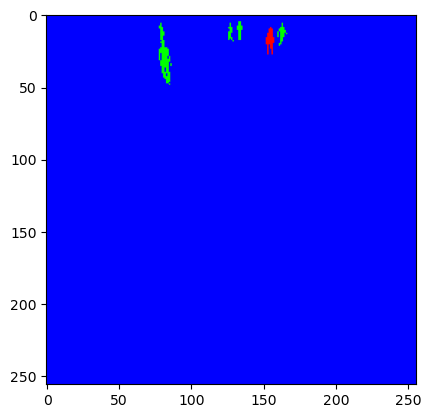

In [9]:
plt.imshow(train_masks[1])

In [10]:
#print(train_masks[1][10:11])
# From here I can see how the segmentation is done on this dataset in that:
# red is the person of interest [255, 0, 0]
# blue is the uninterested region [0, 0, 255]
# green is the people class [0, 255, 0]

In [11]:
def preprocess(images):
    return images/255.0

In [ ]:
train_images = preprocess(train_images)
train_masks = preprocess(train_masks)
valid_images = preprocess(valid_images)
valid_images = preprocess(valid_masks)

## Defining model

In [ ]:
from keras.models import Model
from keras.layers import Conv2D, UpSampling2D, Concatenate, GlobalAveragePooling2D, UpSampling2D
from keras.applications import ResNet50, MobileNetV2

In [ ]:
base = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(256, 256, 3)
)
for i in base.layers:
    print(i.name)
#output = 

In [ ]:
input_shape = (256, 256, 3)
trainable = False
def conv_block(inputs, filters, dilation_rate=1, kernel_size=3, stride=1):
    x = Conv2D(filters, kernel_size, (stride, stride), padding="same", use_bias=False, dilation_rate=(dilation_rate, dilation_rate))(inputs)
    x = BatchNormalization()(x)
    return tf.nn.relu(x)

In [ ]:
def base_model(input_shape=(256, 256, 3), trainable=False):
    base = ResNet50(
        weights="imagenet",
        include_top=False,
        input_shape=input_shape
    )
    base.trainable = trainable
    return base

In [ ]:
def ASPP(input_tensor):
    layer1 = conv_block(input_tensor, 256, 1, 1, 1)
    layer2 = conv_block(input_tensor, 256, 6, 3, 1)
    layer3 = conv_block(input_tensor, 256, 12, 3, 1)
    layer4 = conv_block(input_tensor, 256, 18, 3, 1)
    layer5 = GlobalAveragePooling2D()(input_tensor)
    layer5 = layers.Reshape((1, 1, layer5.shape[-1]))(y5)
    layer5 = conv_block(layer5, 256, kernel_size=1)
    layer5 = layers.UpSampling2D(
        size=(shape[1], shape[2]), interpolation="bilinear")(layer5)
    layers_add = Concatenate([layer1, layer2, layer3, layer4, layer5])
    output = conv_block(layers_add, 256, 1, 1, 1)
    return output

In [ ]:
def encoder(base):
    layers = [
        "conv2_block3_out",
        "conv4_block6_out"
    ]
    layers = [base.get_layer(name).output for name in layers]
    #model_input = base_model(input_tensor, input_shape=input_shape, trainable)
    #model_ouput = ASPP(model_input)
    #encoder_model = Model(model_input, model_output)
    model = Model[base.input, layers]
    return model

In [ ]:
def decoder(base_input, ASPP_input):
    layer1 = UpSampling2D(size=(4, 4), interpolation="bilinear")(ASPP_input)
    layer_add = Concatenate(base_input, layer1)
    layer3 = conv_block(layer_add, 256, 1, 3, 1)
    output = UpSampling2D(size=(4, 4), interpolation="bilinear")(layer3)
    return output

In [ ]:
def deeplabv3plus(num_classes=3):
    base = base_model(input_shape=input_shape, trainable)
    encoder_output = encoder(base)
    low_level, base_output = encoder_output.output
    aspp_out = ASPP(base_output)

    low_level = conv_block(low_level, 48, 1, 1, 1)
    decoder_out = decoder(low_level, aspp_output)
    output = Conv2D(num_classes, 1, padding="same")(decoder_out)
    model = Model(base.input, ouput)
    return model

In [ ]:
model = deeplabv3plus()

## Training and Testing

In [ ]:
learning_rate = 1e-5
epochs = 40

In [ ]:
# Dice Loss and cross entropy loss
def dice_loss(y_true, y_pred):
    return d_loss

cross_entropy_loss = tf.keras.losses.cross_entropy_loss

In [ ]:
# meen IoU
def meanIoU():
    return mIoU

In [ ]:
model.compile(
    optimizer="adam",
    loss=dice_loss + cross_entropy,
    metrics="accuracy"
)

In [ ]:
model.fit(
    X_train, y_train,
    learning_rate,
)